Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ekstraksi file selesai.
Terhubung ke GPU: /device:GPU:0

generator data...
Found 1400 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 984ms/step - accuracy: 0.7079 - loss: 0.5746 - val_accuracy: 0.6975 - val_loss: 0.6220
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.9464 - loss: 0.1752 - val_accuracy: 0.7650 - val_loss: 0.5007
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9864 - loss: 0.0710 - val_accuracy: 0.8000 - val_loss: 0.4208
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9957 - loss: 0.0363 - val_accuracy: 0.8950 - val_loss: 0.2563
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9971 - loss: 0.0205 - val_accuracy: 0.9075 - va

[SUCCESS] Training selesai!

 ekspor model ke Google Drive...

==================== EVALUASI KESELURUHAN DATA TESTING ====================
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
1. Accuracy     : 96.50%
2. Precision    : 96.73%
3. Recall       : 96.50%
4. F1-Score     : 96.50%
5. Confusion Matrix :
[[100   0]
 [  7  93]]

[DRIVE SAVE] Laporan evaluasi teks berhasil disimpan.


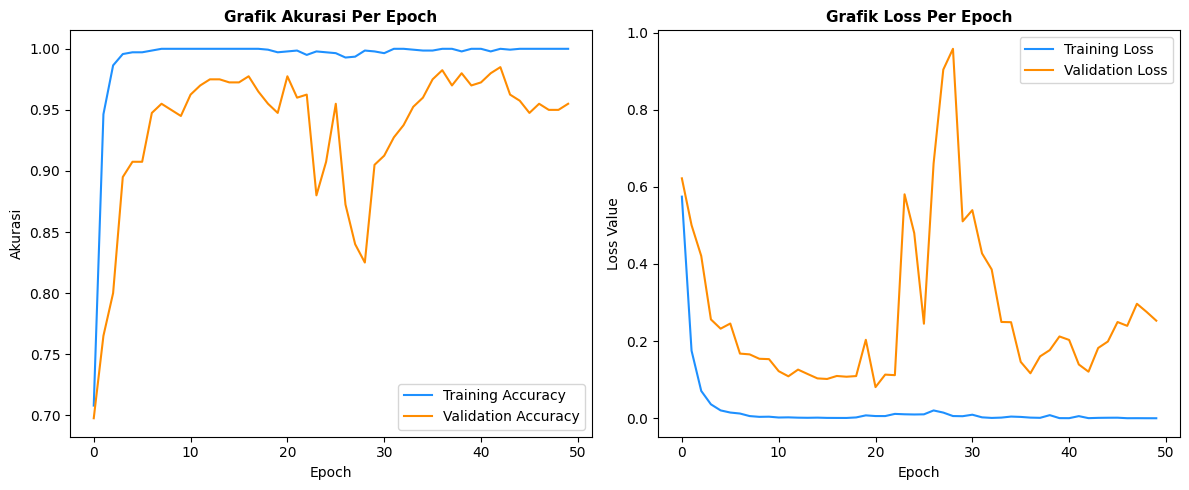

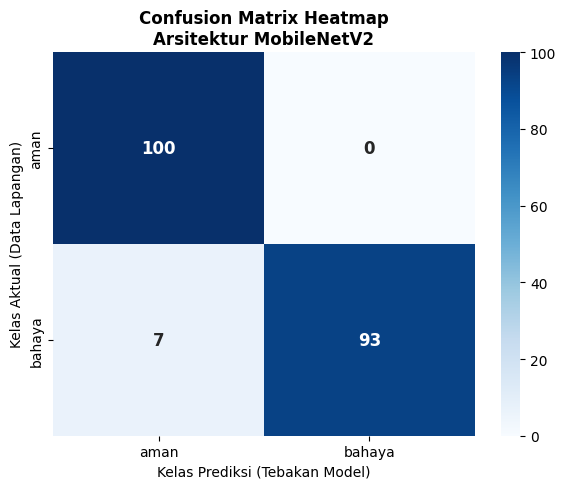


[INFO] Selesai! Semua file hasil evaluasi telah disimpan ke Drive: /content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/mobilenetv2-powerpole


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/power-pole-dataset-70.zip" -d "/content/"
print("Ekstraksi file selesai.")

DATASET_DIR = "/content/power-pole-dataset-70"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "valid")
TEST_DIR = os.path.join(DATASET_DIR, "test")

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/mobilenetv2-powerpole"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
SEED = 42

CATEGORIES = ['aman', 'bahaya']

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("GPU tidak terdeteksi.")
else:
    print(f"Terhubung ke GPU: {device_name}")

print("\ngenerator data...")
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

#TRANSFER LEARNING
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# PROSES TRAINING MODEL
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)
print("[SUCCESS] Training selesai!")

# MENYIMPAN MODEL KE GOOGLE DRIVE (.H5 DAN .TFLITE)
print("\n ekspor model ke Google Drive...")
keras_model_path = os.path.join(DRIVE_OUTPUT_DIR, 'model_tiang_mobilenetv2.h5')
model.save(keras_model_path)

# ==============================================================================
# 6. EVALUASI KESELURUHAN (DIKUNCI PADA 5 EVALUASI UTAMA)
# ==============================================================================
print("\n" + "="*20 + " EVALUASI KESELURUHAN DATA TESTING " + "="*20)
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# 1. Menghitung Nilai Metrik Utama Core
acc_val = accuracy_score(y_true, y_pred)
prec_val = precision_score(y_true, y_pred, average='macro')
rec_val = recall_score(y_true, y_pred, average='macro')
f1_val = f1_score(y_true, y_pred, average='macro')
cm_matrix = confusion_matrix(y_true, y_pred)

# Tampilkan Hasil Evaluasi di Terminal Konsol
print(f"1. Accuracy     : {acc_val * 100:.2f}%")
print(f"2. Precision    : {prec_val * 100:.2f}%")
print(f"3. Recall       : {rec_val * 100:.2f}%")
print(f"4. F1-Score     : {f1_val * 100:.2f}%")
print(f"5. Confusion Matrix :\n{cm_matrix}\n")

# Menyusun Laporan Teks untuk Diekspor ke Drive
evaluasi_text = (
    f"=== LAPORAN EVALUASI KESELURUHAN MODEL MOBILENETV2 ===\n"
    f"Accuracy  : {acc_val * 100:.2f}%\n"
    f"Precision : {prec_val * 100:.2f}%\n"
    f"Recall    : {rec_val * 100:.2f}%\n"
    f"F1-Score  : {f1_val * 100:.2f}%\n\n"
    f"Confusion Matrix Array:\n{cm_matrix}\n"
)
with open(os.path.join(DRIVE_OUTPUT_DIR, 'laporan_evaluasi_keseluruhan.txt'), 'w') as f:
    f.write(evaluasi_text)
print("[DRIVE SAVE] Laporan evaluasi teks berhasil disimpan.")

# Grafik Kemajuan Training Per Epoch (Loss & Accuracy)
epochs_range = range(EPOCHS)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', color='dodgerblue')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.title('Grafik Akurasi Per Epoch', fontsize=11, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', color='dodgerblue')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.title('Grafik Loss Per Epoch', fontsize=11, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT_DIR, 'kurva_training_history.png'), dpi=300)
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES,
            cbar=True, annot_kws={"size": 12, "weight": "bold"})
plt.title('Confusion Matrix Heatmap\nArsitektur MobileNetV2', fontsize=12, fontweight='bold')
plt.ylabel('Kelas Aktual (Data Lapangan)', fontsize=10)
plt.xlabel('Kelas Prediksi (Tebakan Model)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT_DIR, 'confusion_matrix_mobilenetv2.png'), dpi=300)
plt.show()

print(f"\n[INFO] Selesai! Semua file hasil evaluasi telah disimpan ke Drive: {DRIVE_OUTPUT_DIR}")

In [1]:
!unzip -q "/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/power-pole-dataset-70.zip" -d "/content/"
print("Ekstraksi file selesai.")

Ekstraksi file selesai.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

MODEL_PATH = '/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/mobilenetv2-powerpole/model_tiang_mobilenetv2.h5'
TEST_DIR = '/content/power-pole-dataset-70/test'
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/mobilenetv2-powerpole'

CATEGORIES = ['aman', 'bahaya']
IMG_SIZE = (224, 224)

os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

if not os.path.exists(MODEL_PATH):
    print(f"[ERROR] File model tidak ditemukan di: {MODEL_PATH}")
    print("Pastikan proses training sudah selesai dan file .h5 sudah tersimpan.")
else:
    print("[INFO] Memuat model MobileNetV2 dari Google Drive...")
    model = load_model(MODEL_PATH)
    print("[SUCCESS] Model berhasil dimuat!\n")

list_nama_file = []
list_label_aktual = []
list_prediksi_model = []
list_prob_aman = []
list_prob_bahaya = []
list_status = []

print("[PROSES] Mulai menguji seluruh gambar di folder testing...")
print("-" * 60)

for category in CATEGORIES:
    subfolder_path = os.path.join(TEST_DIR, category)
    if not os.path.exists(subfolder_path):
        continue

    file_list = sorted([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    print(f"Menguji kelas '{category}' -> Ditemukan {len(file_list)} gambar.")

    for img_name in file_list:
        img_path = os.path.join(subfolder_path, img_name)
        try:
            img = load_img(img_path, target_size=IMG_SIZE)
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)

            # Prediksi menggunakan MobileNetV2
            preds = model.predict(x, verbose=0)[0]
            idx_prediksi = np.argmax(preds)
            label_prediksi = CATEGORIES[idx_prediksi]

            # Ambil nilai probabilitas masing-masing kelas
            prob_aman_val = preds[0] * 100
            prob_bahaya_val = preds[1] * 100

            # Evaluasi status tebakan
            status = "BENAR" if category == label_prediksi else "SALAH"

            # rekap data
            list_nama_file.append(img_name)
            list_label_aktual.append(category)
            list_prediksi_model.append(label_prediksi)
            list_prob_aman.append(f"{prob_aman_val:.2f}%")
            list_prob_bahaya.append(f"{prob_bahaya_val:.2f}%")
            list_status.append(status)

        except Exception as e:
            print(f"Terjadi kendala pada file {img_name}: {e}")

print("-" * 60)
print("Pengujian seluruh sampel selesai!")

# Membuat tabel representasi data menggunakan Pandas
df_rekap_pengujian = pd.DataFrame({
    'Nama_File': list_nama_file,
    'Label_Aktual': list_label_aktual,
    'Prediksi_Model': list_prediksi_model,
    'Probabilitas_Aman': list_prob_aman,
    'Probabilitas_Bahaya': list_prob_bahaya,
    'Status_Prediksi': list_status
})

# Menentukan jalur penyimpanan file CSV langsung ke dalam Drive
csv_output_path = os.path.join(DRIVE_OUTPUT_DIR, 'rekapan_hasil_pengujian_testing.csv')
df_rekap_pengujian.to_csv(csv_output_path, index=False)

print(f"\n[DRIVE SAVE] File rekapan spreadsheet sukses disimpan!")
print(f"Silakan cek di Drive kamu dengan nama file: '{csv_output_path}'")

# Tampilkan ringkasan 5 baris data teratas di terminal Colab sebagai sampel
print("\nSampel isi data tabel CSV yang berhasil dibuat:")
print(df_rekap_pengujian.head())

[INFO] Memuat model MobileNetV2 dari Google Drive...


[SUCCESS] Model berhasil dimuat!

[PROSES] Mulai menguji seluruh gambar di folder testing...
------------------------------------------------------------
Menguji kelas 'aman' -> Ditemukan 100 gambar.
Menguji kelas 'bahaya' -> Ditemukan 100 gambar.
------------------------------------------------------------
Pengujian seluruh sampel selesai!

[DRIVE SAVE] File rekapan spreadsheet sukses disimpan!
Silakan cek di Drive kamu dengan nama file: '/content/drive/MyDrive/SEMESTER 6/ML/MobileNetV2-power-pole/mobilenetv2-powerpole/rekapan_hasil_pengujian_testing.csv'

Sampel isi data tabel CSV yang berhasil dibuat:
                                           Nama_File Label_Aktual  \
0  IMG_0920_JPG.rf.689b51a92ae18160be74eed41feffc...         aman   
1  IMG_1011_JPG.rf.03343d3b0207377471a7fa7b0ff6fc...         aman   
2  IMG_1050_JPG.rf.e6aa53a200a9c98b81563d17b3be58...         aman   
3  IMG_1088_JPG.rf.28cb7b9c60a06510f510c88a8c7cff...         aman   
4  IMG_1140_JPG.rf.d7d6697457c843b929ea0c11

In [5]:
from google.colab import runtime
runtime.unassign()